Using device: cpu
=== Загрузка датасета STL10 ===
Train: 4000, Val: 1000, Test: 8000
Image shape: torch.Size([3, 96, 96]), Label: 0


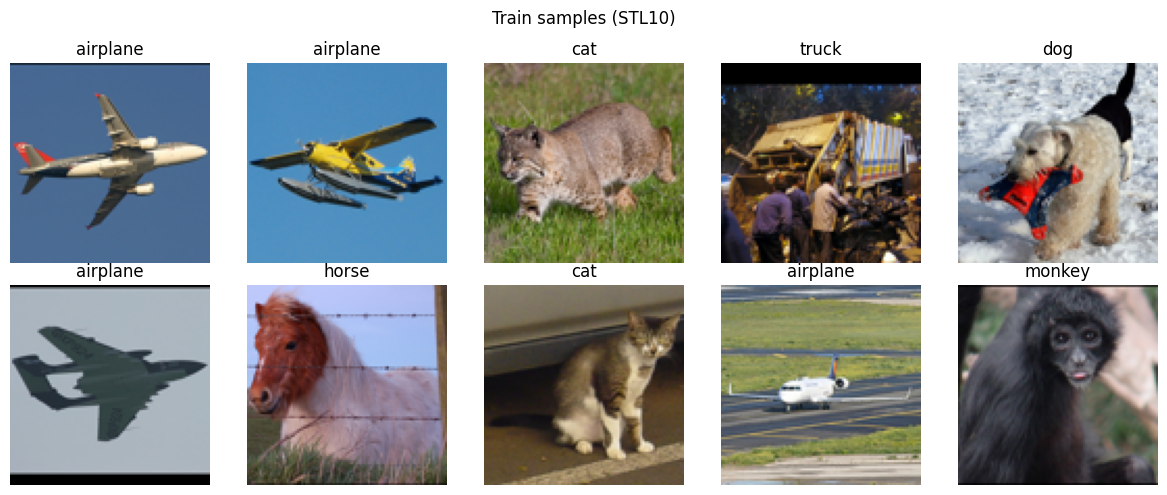

=== C1 ===
Epoch 1: train_loss=2.545, val_loss=1.710, val_acc=32.60%
Epoch 2: train_loss=1.770, val_loss=1.579, val_acc=37.70%
Epoch 3: train_loss=1.642, val_loss=1.473, val_acc=44.00%
Epoch 4: train_loss=1.530, val_loss=1.438, val_acc=45.80%
Epoch 5: train_loss=1.493, val_loss=1.390, val_acc=46.60%

=== C2 ===
Epoch 1: val_acc=31.30%
Epoch 2: val_acc=29.50%
Epoch 3: val_acc=30.90%
Epoch 4: val_acc=36.70%
Epoch 5: val_acc=35.10%

=== C3 ===
Epoch 1: val_acc=92.50%
Epoch 2: val_acc=93.70%
Epoch 3: val_acc=94.00%
Epoch 4: val_acc=94.30%
Epoch 5: val_acc=94.00%

=== C4 ===
Epoch 1: val_acc=93.90%
Epoch 2: val_acc=94.70%
Epoch 3: val_acc=94.30%
Epoch 4: val_acc=94.70%
Epoch 5: val_acc=94.60%

 Best experiment by val_accuracy: C4 (94.70%)
 Test accuracy of best model: 94.54%


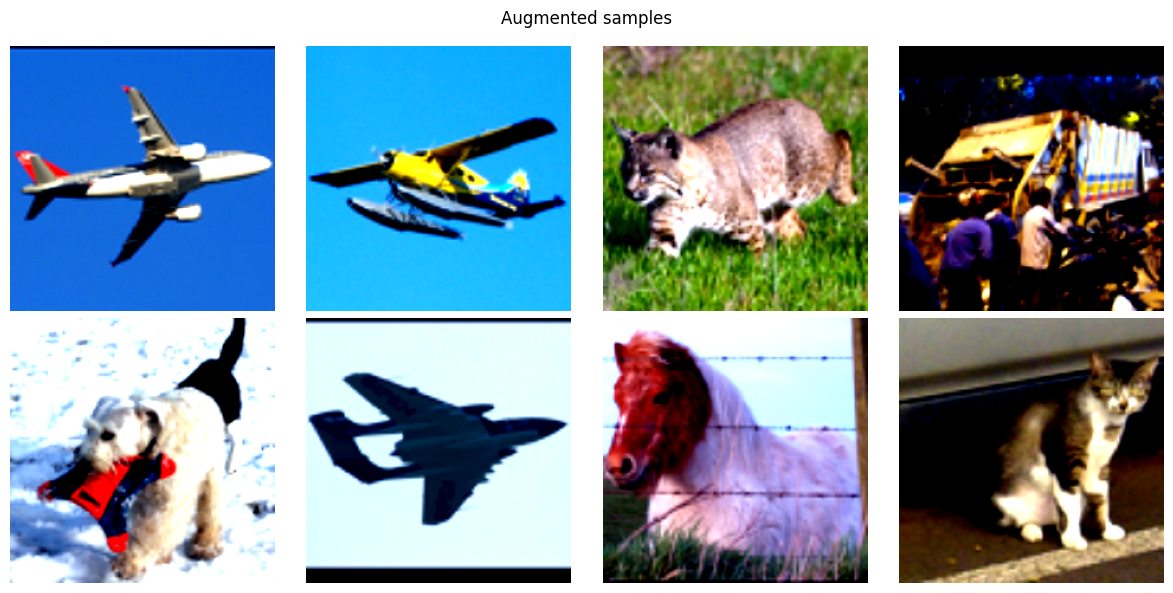

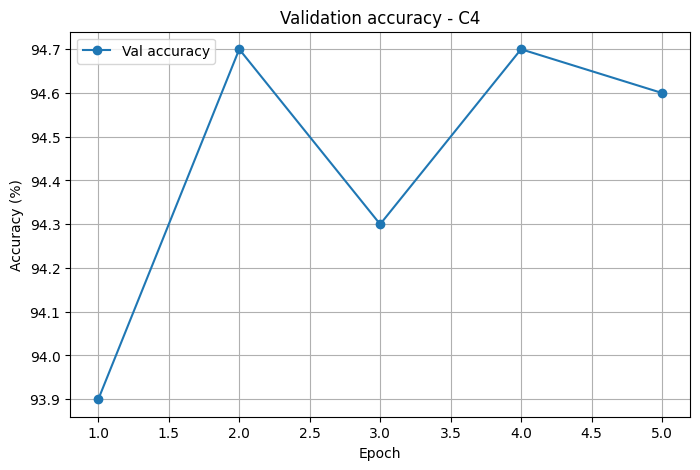

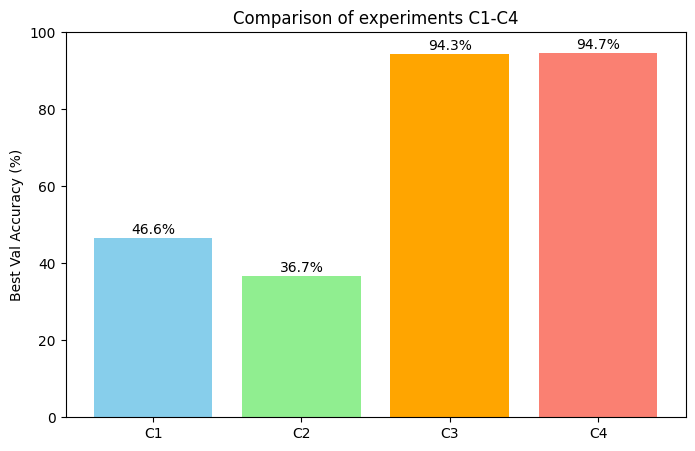


=== ЧАСТЬ B: Сегментация (OxfordIIITPet) ===
Segmentation: train=2944, val=736
Image: torch.Size([3, 224, 224]), Mask: (224, 224), Unique: tensor([1, 2, 3], dtype=torch.uint8)


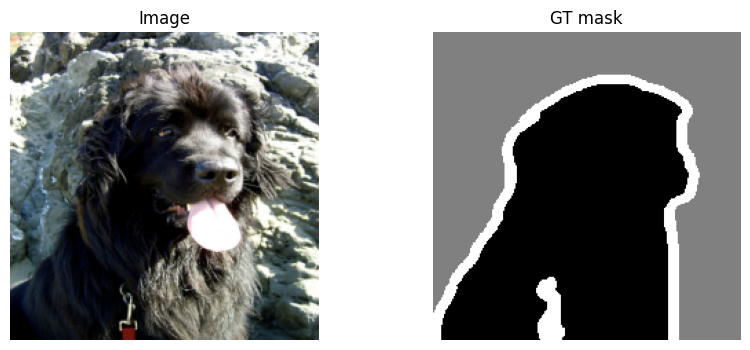

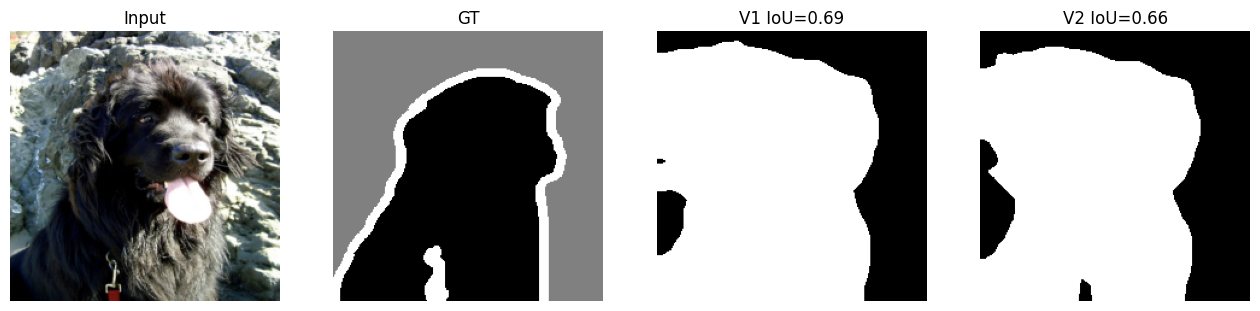

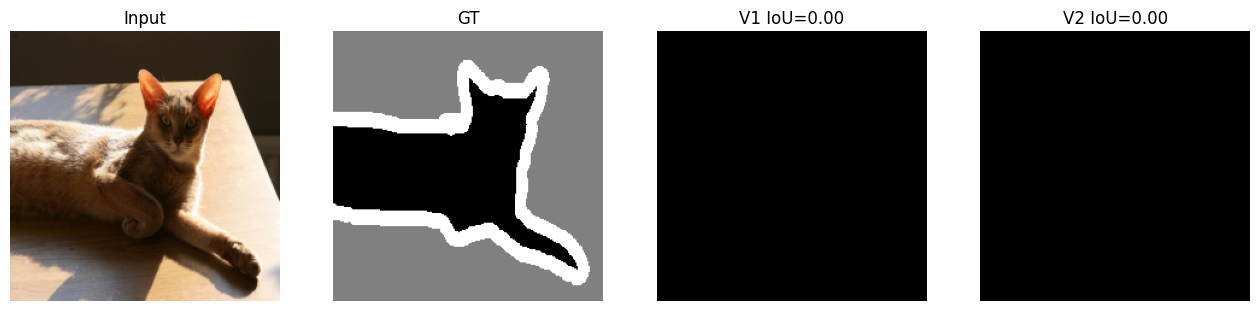

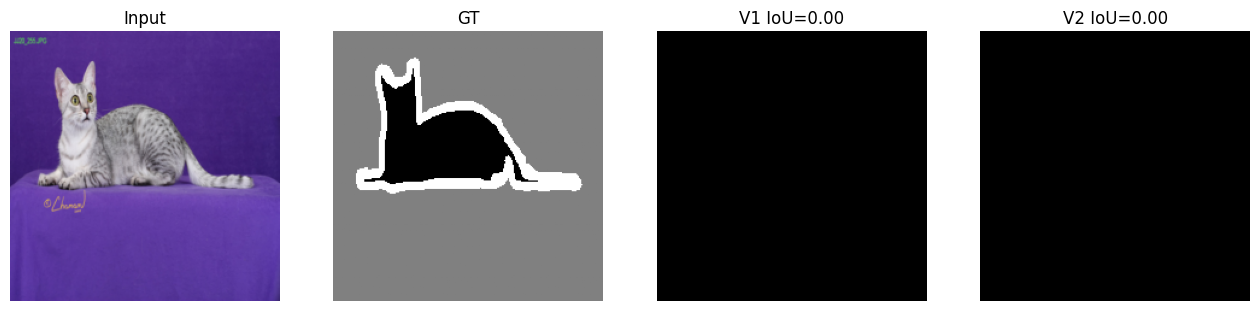

Mean IoU V1 (basic): 0.178
Mean IoU V2 (cleaned): 0.165

Saved artifacts/runs.csv
  experiment_id            task  best_val_accuracy  test_accuracy  mean_iou
0            C1  classification               46.6            NaN       NaN
1            C2  classification               36.7            NaN       NaN
2            C3  classification               94.3            NaN       NaN
3            C4  classification               94.7        94.5375       NaN
4            V1    segmentation                NaN            NaN  0.177876
5            V2    segmentation                NaN            NaN  0.164930


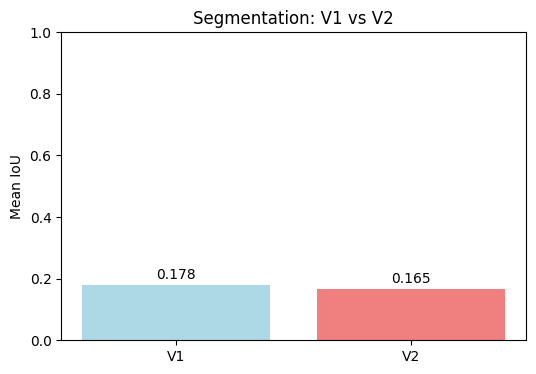

In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

#Часть A 
print("=== Загрузка датасета STL10 ===")

transform_cnn_base = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

transform_cnn_aug = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_full = datasets.STL10(root='./data', split='train', transform=transform_cnn_base, download=True)
test_dataset = datasets.STL10(root='./data', split='test', transform=transform_cnn_base, download=True)

train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(
    train_full, [train_size, val_size], 
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}, Label: {train_dataset[0][1]}")


# Sanity-check 
def show_images(dataset, n=10, title="Samples"):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.ravel()
    classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
    
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)
        img = img * 0.5 + 0.5  # denormalize
        img = img.clamp(0, 1)
        axes[i].imshow(img)
        axes[i].set_title(classes[label])
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "samples.png")
    plt.show()

show_images(train_dataset, title="Train samples (STL10)")

#CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

#Функции обучения и оценки
def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total


#Эксперименты C1-C4 

from torch.optim.lr_scheduler import StepLR
import time

results = []
criterion = nn.CrossEntropyLoss()

# === C1 ===
print("=== C1 ===")
train_dataset.dataset.transform = transform_cnn_base
val_dataset.dataset.transform = transform_cnn_base
test_dataset.transform = transform_cnn_base

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

model_c1 = SimpleCNN().to(device)
optimizer = optim.Adam(model_c1.parameters(), lr=1e-3)
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(5):
    t_loss, t_acc = train_one_epoch(model_c1, train_loader, criterion, optimizer, device, epoch)
    v_loss, v_acc = evaluate(model_c1, val_loader, criterion, device)
    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc); val_accs.append(v_acc)
    print(f"Epoch {epoch+1}: train_loss={t_loss:.3f}, val_loss={v_loss:.3f}, val_acc={v_acc:.2f}%")

results.append({
    'experiment_id': 'C1', 'task': 'classification', 'dataset': 'STL10',
    'seed': SEED, 'model_summary': 'SimpleCNN', 'optimizer': 'Adam',
    'lr': 1e-3, 'epochs_trained': 15,
    'best_val_accuracy': max(val_accs), 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'No augmentations'
})

# === C2 ===
print("\n=== C2 ===")
train_dataset.dataset.transform = transform_cnn_aug
train_loader_aug = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)

model_c2 = SimpleCNN().to(device)
optimizer = optim.Adam(model_c2.parameters(), lr=1e-3)
train_losses_c2, val_accs_c2 = [], []

for epoch in range(5):
    t_loss, t_acc = train_one_epoch(model_c2, train_loader_aug, criterion, optimizer, device, epoch)
    v_loss, v_acc = evaluate(model_c2, val_loader, criterion, device)
    train_losses_c2.append(t_loss); val_accs_c2.append(v_acc)
    print(f"Epoch {epoch+1}: val_acc={v_acc:.2f}%")

results.append({
    'experiment_id': 'C2', 'task': 'classification', 'dataset': 'STL10',
    'seed': SEED, 'model_summary': 'SimpleCNN', 'optimizer': 'Adam',
    'lr': 1e-3, 'epochs_trained': 5,
    'best_val_accuracy': max(val_accs_c2), 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'With augmentations'
})

# === C3 ===
print("\n=== C3 ===")
train_dataset.dataset.transform = transform_resnet
val_dataset.dataset.transform = transform_resnet
test_dataset.transform = transform_resnet

train_loader_rn = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader_rn = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

model_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_c3.parameters():
    param.requires_grad = False
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, 10)
model_c3 = model_c3.to(device)

optimizer = optim.Adam(model_c3.fc.parameters(), lr=1e-3)
val_accs_c3 = []

for epoch in range(5):
    t_loss, t_acc = train_one_epoch(model_c3, train_loader_rn, criterion, optimizer, device, epoch)
    v_loss, v_acc = evaluate(model_c3, val_loader_rn, criterion, device)
    val_accs_c3.append(v_acc)
    print(f"Epoch {epoch+1}: val_acc={v_acc:.2f}%")

results.append({
    'experiment_id': 'C3', 'task': 'classification', 'dataset': 'STL10',
    'seed': SEED, 'model_summary': 'ResNet18_pretrained_head_only', 'optimizer': 'Adam',
    'lr': 1e-3, 'epochs_trained': 5,
    'best_val_accuracy': max(val_accs_c3), 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'Frozen backbone, train fc only'
})

# === C4 ===
print("\n=== C4 ===")
model_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model_c4.layer4.parameters():
    param.requires_grad = True
for param in list(model_c4.parameters())[:-7]:
    param.requires_grad = False
model_c4.fc = nn.Linear(model_c4.fc.in_features, 10)
model_c4 = model_c4.to(device)

optimizer = optim.Adam([
    {'params': model_c4.layer4.parameters(), 'lr': 1e-4},
    {'params': model_c4.fc.parameters(), 'lr': 1e-3}
])
val_accs_c4 = []

for epoch in range(5):
    t_loss, t_acc = train_one_epoch(model_c4, train_loader_rn, criterion, optimizer, device, epoch)
    v_loss, v_acc = evaluate(model_c4, val_loader_rn, criterion, device)
    val_accs_c4.append(v_acc)
    print(f"Epoch {epoch+1}: val_acc={v_acc:.2f}%")

results.append({
    'experiment_id': 'C4', 'task': 'classification', 'dataset': 'STL10',
    'seed': SEED, 'model_summary': 'ResNet18_pretrained_finetune', 'optimizer': 'Adam',
    'lr': 1e-3, 'epochs_trained': 5,
    'best_val_accuracy': max(val_accs_c4), 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': None,
    'notes': 'Fine-tune layer4 + fc'
})

# === Выбор лучшей модели и тест ===
all_accs = [max(val_accs), max(val_accs_c2), max(val_accs_c3), max(val_accs_c4)]
best_idx = np.argmax(all_accs)
exp_names = ['C1', 'C2', 'C3', 'C4']
best_exp = exp_names[best_idx]
print(f"\n Best experiment by val_accuracy: {best_exp} ({all_accs[best_idx]:.2f}%)")

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
if best_exp == 'C1': best_model = model_c1
elif best_exp == 'C2': best_model = model_c2
elif best_exp == 'C3': best_model = model_c3
else: best_model = model_c4

_, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f" Test accuracy of best model: {test_acc:.2f}%")

for r in results:
    if r['experiment_id'] == best_exp:
        r['test_accuracy'] = test_acc

torch.save(best_model.state_dict(), ARTIFACTS_DIR / "best_classifier.pt")
best_config = {
    'dataset': 'STL10',
    'model': 'SimpleCNN' if best_exp in ['C1','C2'] else 'ResNet18_pretrained',
    'transform': 'with_aug' if best_exp == 'C2' else 'base',
    'optimizer': 'Adam', 'lr': 1e-3, 'epochs': 5, 'seed': SEED,
    'best_val_accuracy': all_accs[best_idx], 'test_accuracy': test_acc
}
with open(ARTIFACTS_DIR / "best_classifier_config.json", 'w') as f:
    json.dump(best_config, f, indent=2)


# Визуализация аугментаций и метрик

def show_augmentations(dataset, n=8):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    for i in range(n):
        img, _ = dataset[i]
        img = img.permute(1, 2, 0)
        img = img * 0.5 + 0.5
        img = img.clamp(0, 1)
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.suptitle("Augmented samples")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "augmentations_preview.png")
    plt.show()

show_augmentations(train_dataset)

# Графики для лучшей модели
epochs = range(1, 6)
plt.figure(figsize=(8, 5))
if best_exp == 'C1':
    plt.plot(epochs, train_losses, label='Train loss')
    plt.plot(epochs, val_losses, label='Val loss')
    plt.title(f"Loss curves - {best_exp}")
elif best_exp == 'C2':
    plt.plot(epochs, train_losses_c2, label='Train loss')
    plt.title(f"Train loss - {best_exp}")
elif best_exp in ['C3', 'C4']:
    accs = val_accs_c3 if best_exp=='C3' else val_accs_c4
    plt.plot(epochs, accs, label='Val accuracy', marker='o')
    plt.title(f"Validation accuracy - {best_exp}")
    plt.ylabel('Accuracy (%)')

plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
plt.savefig(FIGURES_DIR / "classification_curves_best.png"); plt.show()

# Сравнение C1-C4
exp_ids = ['C1', 'C2', 'C3', 'C4']
val_accs_all = [max(val_accs), max(val_accs_c2), max(val_accs_c3), max(val_accs_c4)]
plt.figure(figsize=(8, 5))
plt.bar(exp_ids, val_accs_all, color=['skyblue', 'lightgreen', 'orange', 'salmon'])
plt.ylabel('Best Val Accuracy (%)'); plt.title('Comparison of experiments C1-C4')
plt.ylim(0, 100)
for i, v in enumerate(val_accs_all):
    plt.text(i, v+1, f'{v:.1f}%', ha='center')
plt.savefig(FIGURES_DIR / "classification_compare.png"); plt.show()

# Часть B 

print("\n=== ЧАСТЬ B: Сегментация (OxfordIIITPet) ===")

seg_dataset = datasets.OxfordIIITPet(
    root='./data_seg', split='trainval', target_types='segmentation',
    transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]),
    target_transform=transforms.Compose([
        transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
    ]),
    download=True
)

seg_train_size = int(0.8 * len(seg_dataset))
seg_val_size = len(seg_dataset) - seg_train_size
seg_train, seg_val = random_split(
    seg_dataset, [seg_train_size, seg_val_size],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Segmentation: train={len(seg_train)}, val={len(seg_val)}")

# Sanity check 
img, mask = seg_val[0]

if isinstance(img, torch.Tensor):
    img_shape = img.shape
    mask_shape = mask.shape if isinstance(mask, torch.Tensor) else np.array(mask).shape
    unique_vals = torch.unique(mask) if isinstance(mask, torch.Tensor) else torch.unique(torch.tensor(np.array(mask)))
else:

    img_shape = (3,) + img.size[::-1]  # (C, H, W)
    mask_shape = np.array(mask).shape
    unique_vals = torch.unique(torch.tensor(np.array(mask)))

print(f"Image: {img_shape}, Mask: {mask_shape}, Unique: {unique_vals}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

if isinstance(img, torch.Tensor):
    img_vis = img.permute(1, 2, 0)
    mask_vis = mask.squeeze() if isinstance(mask, torch.Tensor) else np.array(mask)
else:
    img_vis = np.array(img)
    mask_vis = np.array(mask)

ax1.imshow(img_vis)
ax1.set_title("Image")
ax1.axis('off')

ax2.imshow(mask_vis, cmap='gray')
ax2.set_title("GT mask")
ax2.axis('off')

plt.savefig(FIGURES_DIR / "segmentation_example_gt.png")
plt.show()


# Pretrained модель сегментации + валидация (V1, V2)

seg_model = deeplabv3_resnet50(weights=models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1)
seg_model = seg_model.eval().to(device)

def postprocess_mask(output, mode='basic', threshold=0.5):
    probs = torch.softmax(output['out'], dim=1)
    foreground_prob = probs[:, 11:13].sum(dim=1)
    if mode == 'basic':
        mask = (foreground_prob > threshold).float()
    else:  
        mask = (foreground_prob > (threshold + 0.1)).float()
    return mask.squeeze(0)

def compute_iou(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    target_bin = (target > 0).float()
    target_bin[target == 255] = 0
    intersection = (pred_bin * target_bin).sum()
    union = ((pred_bin + target_bin) > 0).float().sum()
    return (intersection / union).item() if union > 0 else 1.0

val_results = {'V1': [], 'V2': []}

with torch.no_grad():
    for i in range(min(20, len(seg_val))):
        img, mask = seg_val[i]
        
        if not isinstance(img, torch.Tensor):
            img = transforms.ToTensor()(img)
        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(np.array(mask)).float()
        
        img_batch = img.unsqueeze(0).to(device)
        mask_gt = mask.squeeze()
        
        output = seg_model(img_batch)
        
        mask_v1 = postprocess_mask(output, mode='basic', threshold=0.5)
        iou_v1 = compute_iou(mask_v1.cpu(), mask_gt)
        
        mask_v2 = postprocess_mask(output, mode='cleaned', threshold=0.5)
        iou_v2 = compute_iou(mask_v2.cpu(), mask_gt)
        
        val_results['V1'].append(iou_v1)
        val_results['V2'].append(iou_v2)
        
        if i < 3:
            fig, axes = plt.subplots(1, 4, figsize=(16, 4))
            axes[0].imshow(img.permute(1,2,0))
            axes[0].set_title("Input")
            axes[0].axis('off')
            axes[1].imshow(mask_gt, cmap='gray')
            axes[1].set_title("GT")
            axes[1].axis('off')
            axes[2].imshow(mask_v1.cpu(), cmap='gray')
            axes[2].set_title(f"V1 IoU={iou_v1:.2f}")
            axes[2].axis('off')
            axes[3].imshow(mask_v2.cpu(), cmap='gray')
            axes[3].set_title(f"V2 IoU={iou_v2:.2f}")
            axes[3].axis('off')
            plt.savefig(FIGURES_DIR / f"segmentation_examples_{i}.png")
            plt.show()

mean_iou_v1 = np.mean(val_results['V1'])
mean_iou_v2 = np.mean(val_results['V2'])
print(f"Mean IoU V1 (basic): {mean_iou_v1:.3f}")
print(f"Mean IoU V2 (cleaned): {mean_iou_v2:.3f}")

results.append({
    'experiment_id': 'V1', 'task': 'segmentation', 'dataset': 'OxfordIIITPet',
    'seed': SEED, 'model_summary': 'DeepLabV3_ResNet50_pretrained', 'optimizer': None,
    'lr': None, 'epochs_trained': 0, 'best_val_accuracy': None, 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': mean_iou_v1,
    'notes': 'Basic postprocessing, threshold=0.5'
})
results.append({
    'experiment_id': 'V2', 'task': 'segmentation', 'dataset': 'OxfordIIITPet',
    'seed': SEED, 'model_summary': 'DeepLabV3_ResNet50_pretrained', 'optimizer': None,
    'lr': None, 'epochs_trained': 0, 'best_val_accuracy': None, 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': mean_iou_v2,
    'notes': 'Cleaned postprocessing, threshold=0.6'
})

# Сохранение результатов и финальные артефакты
df_results = pd.DataFrame(results)
df_results.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
print("\nSaved artifacts/runs.csv")
print(df_results[['experiment_id', 'task', 'best_val_accuracy', 'test_accuracy', 'mean_iou']])

plt.figure(figsize=(6, 4))
plt.bar(['V1', 'V2'], [mean_iou_v1, mean_iou_v2], color=['lightblue', 'lightcoral'])
plt.ylabel('Mean IoU'); plt.title('Segmentation: V1 vs V2'); plt.ylim(0, 1)
for i, v in enumerate([mean_iou_v1, mean_iou_v2]):
    plt.text(i, v+0.02, f'{v:.3f}', ha='center')
plt.savefig(FIGURES_DIR / "segmentation_metrics.png"); plt.show()

